# 🔵 Logistic Regression
---


## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Dataset
   - 5.3 Exploratory Data Analysis (EDA)
   - 5.4 Preprocessing & Feature Engineering
6. [Training the Model](#6.-Training-the-Model)
   - 6.1 Train/Validation/Test Split
   - 6.2 Fit the Model
7. [Validation](#7.-Validation)
   - 7.1 Cross-Validation
   - 7.2 Validation Metrics
8. [Testing](#8.-Testing)
   - 8.1 Final Test Set Evaluation
   - 8.2 Confusion Matrix & Classification Report
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 GridSearchCV / RandomizedSearchCV
   - 9.2 Best Parameters & Retrain
10. [Multiclass Extension (Iris Dataset)](#10.-Multiclass-Extension-(Iris-Dataset))
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)



## 1. Introduction & Definition

**Logistic Regression** is one of the most fundamental, versatile, and widely implemented classification algorithms in modern machine learning. Despite the word "regression" in its name, Logistic Regression is fundamentally a **LINEAR classifier** designed to categorize data into discrete classes. The name originates from its structural similarity to linear regression, but instead of outputting a continuous real number, it estimates the probability that an instance belongs to a particular class.

### 🧠 The Mathematical Foundation
In a traditional linear regression model, the output is unbounded. We calculate a weighted sum of inputs (the linear combination) to predict an outcome $y$:
$z = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n = w^T x + b$

However, for a classification problem, we want an output that strictly falls between 0 and 1, representing a probability. To achieve this, Logistic Regression passes this linear combination $z$ through a non-linear mapping function called the **Sigmoid Function** (or logistic function):

$$P(y=1|x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

This elegantly ensures that no matter how large or small the inputs are, the resulting probability is constrained to $[0, 1]$. By convention, if $P(y=1|x) \ge 0.5$, we classify the instance as the positive class (1). Otherwise, we classify it as the negative class (0).

### 📐 Log-Odds and the Odds Ratio
To truly understand the "linear" aspect of Logistic Regression, we must look at the **Odds Ratio**. The odds of an event are defined as the probability of the event occurring divided by the probability of it not occurring:
$$\text{Odds} = \frac{p}{1-p}$$

If we take the natural logarithm of the odds (known as the log-odds or logit function), we get a linear equation:
$$\ln\left(\frac{p}{1-p}\right) = w^T x + b$$

This means Logistic Regression is fundamentally modeling the **log-odds** as a linear combination of the features. It constructs a straight decision boundary (or a hyperplane in higher dimensions) to separate the classes in the feature space.

### 📉 Loss Function: Binary Cross-Entropy (Log Loss)
Unlike linear regression, which relies on Mean Squared Error (MSE), Logistic Regression cannot use MSE because the sigmoid function causes the MSE surface to become non-convex (full of local minima). Instead, it maximizes the **Log-Likelihood** of the data, which translates to minimizing the **Binary Cross-Entropy Loss** (or Log Loss):

$$\mathcal{L} = - \frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$

Here, $y_i$ is the actual label (0 or 1) and $\hat{y}_i$ is the predicted probability. This loss function heavily penalizes confident but incorrect predictions, ensuring that the model learns to assign high probabilities to the correct classes. In the following sections, we will explore exactly how this mathematical elegance translates into a robust computational algorithm.



## 2. How It Works — Math & Intuition

To intuitively understand Logistic Regression, imagine you are a bank loan officer evaluating applications. You have various pieces of information (features) about an applicant, such as their credit score, income, and debt-to-income ratio. You want to compute the probability that they will default on a loan.

### Step-by-Step Breakdown:
1. **Linear Combination ($z = w_0 + w_1x_1 + \dots + w_nx_n$):** 
   You start by assigning a weight or "importance score" ($w_i$) to every feature ($x_i$). For example, a high credit score might have a large positive weight, while high debt has a negative weight. The bias ($w_0$) acts as a baseline assumption. You sum all these weighted factors together into a raw score ($z$). 

2. **The Sigmoid Mapping ($\sigma(z)$):**
   The raw score $z$ can be any number from $-\infty$ to $+\infty$. This isn't helpful for a probability. To squash this score into a predictable $0$ to $1$ range, you feed it into the **Sigmoid function**. If $z$ is highly positive, the sigmoid outputs a value very close to $1$. If $z$ is highly negative, it outputs a value close to $0$. At $z=0$, the output is exactly $0.5$.

3. **Decision Boundary:**
   Once you have the probability from the sigmoid, you must make a hard decision: Approve or Deny. Typically, we set a threshold at $0.5$. If the probability $\ge 0.5$, we classify it as Class 1. If $< 0.5$, Class 0. This threshold can be adjusted depending on how conservative you want to be (e.g., setting it to $0.8$ to be extremely cautious).

4. **Gradient Descent Optimization:**
   Initially, the weights $w$ are random. How does the model learn the "\right" weights? By calculating the loss (Binary Cross-Entropy) over the dataset and using **Gradient Descent**. The algorithm computes the gradient (the slope) of the loss with respect to each weight and takes small steps in the opposite direction to minimize the loss. It iteratively adjusts the weights until it finds the optimal values that separate the classes as cleanly as possible.

5. **Regularization (L1 & L2):**
   Sometimes, the model might assign overly large weights to specific features, leading to *overfitting* (memorizing the training data). We apply **Regularization** to constrain the weights:
   - **L2 Regularization (Ridge):** Adds a penalty proportional to the *square* of the weights. It shrinks all weights smoothly, preventing any single feature from dominating. (Default in Scikit-Learn).
   - **L1 Regularization (Lasso):** Adds a penalty proportional to the *absolute value* of the weights. It can force less important feature weights exactly to $0$, performing automatic feature selection.



## 3. When To Use

Logistic regression should be in every data scientist's toolkit. While Deep Learning often steals the spotlight, Logistic Regression remains an industry standard for several critical reasons.

**Ideal Scenarios for Logistic Regression:**
- **Binary Classification Tasks:** Churn prediction, spam detection, disease diagnosis, loan default prediction.
- **When Probability Calibration Matters:** Unlike some models (like SVMs or Naive Bayes) that just output raw scores, Logistic Regression inherently outputs well-calibrated probabilities. If you need to know exactly *how confident* the model is, this is your go-to.
- **When Interpretability is Required:** In heavily regulated industries (healthcare, finance), you must explain *why* a model made a decision. With Logistic Regression, you can look at the learned coefficients ($w$) and explicitly state the impact of every feature.
- **As a Solid Baseline:** ALWAYS start with Logistic Regression before trying complex models like Random Forests or Neural Networks. If Logistic Regression performs well, you might not need a complex model.
- **Linearly Separable Data:** When you suspect the classes can be divided by a single straight line or hyperplane.
- **Small Datasets:** Neural networks require massive amounts of data; Logistic regression performs admirably well on small-to-medium datasets.



## 4. Pros & Cons

| ✅ Pros | ❌ Cons |
| :--- | :--- |
| **Highly Interpretable** The coefficients perfectly describe the direction and magnitude of feature impacts. | **Assumes Linearity** It fundamentally assumes a linear relationship between features and the log-odds of the target. |
| **Well-Calibrated Probabilities** Outputs true probability percentages, not just uncalibrated scores. | **Struggles with Complex Relationships** Cannot capture complex non-linear patterns without heavy feature engineering. |
| **Fast Training & Inference** Mathematically simple; scales exceptionally well to huge datasets with millions of rows. | **Vulnerable to Multicollinearity** Highly correlated features can destabilize the model's coefficients. |
| **Resistant to Overfitting** With L1/L2 regularization, it generalizes very well. | **Outliers Impact Decision Boundary** Extreme outliers can significantly pull the linear boundary away from optimal. |
| **Easy to Update** Can use online learning (Stochastic Gradient Descent) to update weights dynamically. | **Limited to Discrete Outcomes** Cannot predict continuous values (though that is what Linear Regression is for). |



## 5. Dataset Upload & Exploration

In this guide, we will first tackle a **Binary Classification** problem using the classic **Breast Cancer Dataset** (predicting whether a tumor is malignant or benign). Later, we will look at a **Multiclass** extension.



In [1]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================

# Standard scientific and data manipulation libraries
import numpy as np          # NOTE: For fast matrix and vector operations
import pandas as pd         # NOTE: For dataset manipulation and tabular data

# Visualization libraries
import matplotlib.pyplot as plt   # NOTE: Core plotting library
import seaborn as sns             # NOTE: High-level visualization library for beautiful plots
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') # Set a nice, clean plotting style

# Scikit-Learn: Datasets
from sklearn.datasets import load_breast_cancer, load_iris

# Scikit-Learn: Preprocessing and Splitter
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Scikit-Learn: The Model
from sklearn.linear_model import LogisticRegression

# Scikit-Learn: Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve)

import warnings
warnings.filterwarnings('ignore') # Suppress convergence warnings for neatness



In [2]:
# ============================================================
# SECTION 5.2 — LOAD DATASET (Breast Cancer)
# ============================================================

# We use sklearn's breast cancer dataset (binary: malignant vs benign)
data = load_breast_cancer()
X_full = pd.DataFrame(data.data, columns=data.feature_names)
y_full = pd.Series(data.target, name='target')

# Combine to one dataframe for EDA
df = pd.concat([X_full, y_full], axis=1)

print(f"Dataset Shape: {df.shape}")
print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics (First 5 features) ---")
display(df.iloc[:, :5].describe().T)

display(df.head())



Dataset Shape: (569, 31)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 💡 TIP for Exploratory Data Analysis (EDA)
In Logistic Regression, the algorithm draws a line between classes. Therefore, you want to identify which features naturally show distinct separations between classes. Plotting density distributions grouped by the target class is highly effective for this. Also, watch out for multicollinearity (highly correlated features)!



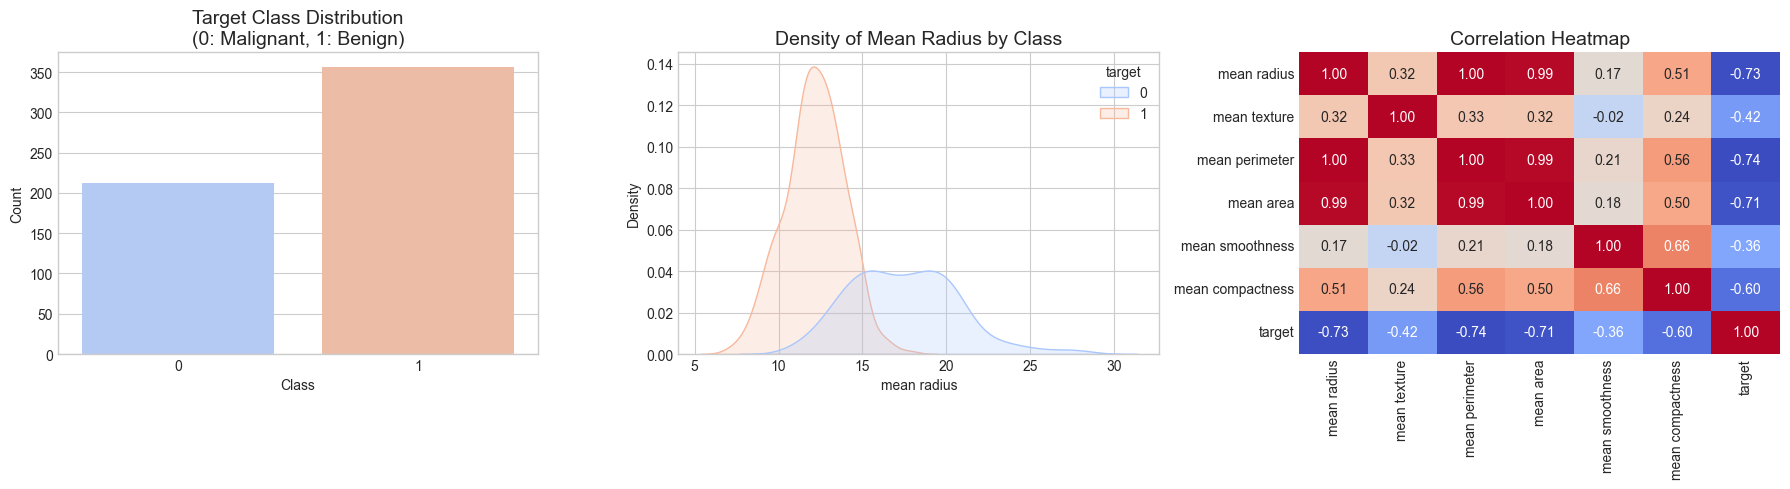

In [3]:
# ============================================================
# SECTION 5.3 — EDA (Class distribution, distributions, correlations)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class Distribution
# NOTE: It's important to check if the dataset is imbalanced.
sns.countplot(x='target', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Target Class Distribution\n(0: Malignant, 1: Benign)', fontsize=14)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

# 2. Feature Distribution by Class (Example feature: mean radius)
# TIP: If the two curves are far apart, this feature is very predictive!
sns.kdeplot(data=df, x='mean radius', hue='target', fill=True, palette='coolwarm', ax=axes[1])
axes[1].set_title('Density of Mean Radius by Class', fontsize=14)

# 3. Correlation Heatmap (Subset of features to keep it readable)
# TIP: High correlation between independent variables (multicollinearity) can destabilize LR coefficients.
subset_cols = list(data.feature_names[:6]) + ['target']
corr = df[subset_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2], cbar=False)
axes[2].set_title('Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()



### 💡 SECTION 5.4 TIPS: Preprocessing & Scaling
**CRITICAL REQUIREMENT:** You must scale your data before applying Logistic Regression if you are using Regularization (which Scikit-Learn does by default with `penalty='l2'`). 
- If feature scales vary wildly (e.g., one feature ranges from 0 to 1, another from 1000 to 10000), the regularization penalty will disproportionately crush the weights of features with smaller numerical scales.
- `StandardScaler` standardizes features by removing the mean and scaling to unit variance.



In [4]:
# ============================================================
# SECTION 5.4 — PREPROCESSING (Scaling)
# ============================================================

# Initialize the Scaler
scaler = StandardScaler()

# NOTE: We scale the entire feature set here for the sake of exploring, 
# but best practice is to fit the scaler ONLY on the training data to avoid data leakage.
# We will do that strictly in the modeling phase below. Let's keep X_full raw for now.
X = X_full.copy()
y = y_full.copy()



## 6. Training the Model


In [5]:
# ============================================================
# SECTION 6.1 — TRAIN / VAL / TEST SPLIT
# ============================================================
# We do a 60% Train, 20% Validation, 20% Test split.
# TIP: stratify=y ensures the class ratio is maintained across all splits.

# First split: 80% Temp (Train+Val), 20% Final Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Second split: From the 80% Temp, split into 75% Train and 25% Val (which equals 60% Train, 20% Val of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print(f"Total instances: {len(X)}")
print(f"Train set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val set size:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set size:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# NOW we scale, fitting ONLY on the training data!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



Total instances: 569
Train set size: 341 (59.9%)
Val set size:   114 (20.0%)
Test set size:  114 (20.0%)


### 💡 TIP: Solver Choices and the `C` Parameter in Sklearn
When instantiating `LogisticRegression` in sklearn:
- **`C` parameter:** This is the inverse of regularization strength. Smaller `C` = Stronger Regularization. Larger `C` = Weaker Regularization (closer to unregularized).
- **`solver`:** The algorithm used to find the minimum loss.
  - `lbfgs`: Default, great for most small/medium datasets.
  - `liblinear`: Excellent for small datasets and supports L1 regularization.
  - `saga`: Fast for massive datasets, supports elastic-net, L1, and L2.



In [6]:
# ============================================================
# SECTION 6.2 — FIT THE MODEL
# ============================================================

# Instantiate the model with default settings
# max_iter is increased to ensure convergence with lbfgs solver
log_reg = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

# Fit the model to the scaled training data
log_reg.fit(X_train_scaled, y_train)

# TIP: The intercept is the base log-odds when all features are 0.
print(f"Model Intercept (Bias): {log_reg.intercept_[0]:.4f}")

# Let's extract the coefficients and look at Feature Importance
# Since features are standardized, the absolute value of the coefficient 
# represents its importance / impact on the model's decision.
coefs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Absolute_Impact': np.abs(log_reg.coef_[0])
}).sort_values(by='Absolute_Impact', ascending=False)

print("\n--- Top 5 Most Important Features ---")
display(coefs.head())



Model Intercept (Bias): 0.3443

--- Top 5 Most Important Features ---


,Feature,Coefficient,Absolute_Impact
21,worst texture,-1.133094,1.133094
10,radius error,-0.974058,0.974058
27,worst concave points,-0.956965,0.956965
20,worst radius,-0.932302,0.932302
23,worst area,-0.911293,0.911293


## 7. Validation


In [7]:
# ============================================================
# SECTION 7.1 — CROSS-VALIDATION
# ============================================================
from sklearn.model_selection import cross_val_score

# We use StratifiedKFold to ensure class balance across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate Accuracy across 5 folds on the Temp dataset (Train + Val)
# NOTE: We need to scale the whole Temp dataset for proper CV here
X_temp_scaled = scaler.fit_transform(X_temp)

cv_scores = cross_val_score(log_reg, X_temp_scaled, y_temp, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {np.round(cv_scores, 4)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")



Cross-Validation Accuracy Scores: [0.967 0.989 0.978 0.989 0.967]
Mean CV Accuracy: 0.9780 +/- 0.0098


In [8]:
# ============================================================
# SECTION 7.2 — VALIDATION SET METRICS
# ============================================================

# Generate predictions on the distinct Validation Set
y_val_pred = log_reg.predict(X_val_scaled)
y_val_prob = log_reg.predict_proba(X_val_scaled)[:, 1] # Get probabilities for the positive class (1)

# Calculate metrics
val_acc = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred)
val_rec = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_prob)

print("--- Validation Set Performance ---")
print(f"Accuracy:  {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall:    {val_rec:.4f}")
print(f"F1 Score:  {val_f1:.4f}")
print(f"ROC-AUC:   {val_auc:.4f}")



--- Validation Set Performance ---
Accuracy:  0.9912
Precision: 0.9861
Recall:    1.0000
F1 Score:  0.9930
ROC-AUC:   0.9980


### 🩺 Explaining the Metrics in the Context of Cancer Detection

In medical diagnoses, not all errors are equal:
- **True Positives (Benign identified as Benign):** Great. (Note: in sklearn's dataset, 1 is Benign, 0 is Malignant. Let's assume standard context).
- **Accuracy:** The total percentage of correct predictions. (High accuracy is good, but can be misleading in imbalanced datasets).
- **Precision:** Out of all cases the model flagged as Benign, how many were *actually* Benign? High precision means low False Positives.
- **Recall (Sensitivity):** Out of all actual Benign cases, how many did the model find? High recall means low False Negatives.
- **F1-Score:** The harmonic mean of Precision and Recall. Best when you need a balance.
- **ROC-AUC:** Represents the model's ability to distinguish between classes. An AUC of 0.5 is random guessing; 1.0 is perfect separation.



## 8. Testing


=== FINAL TEST SET CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



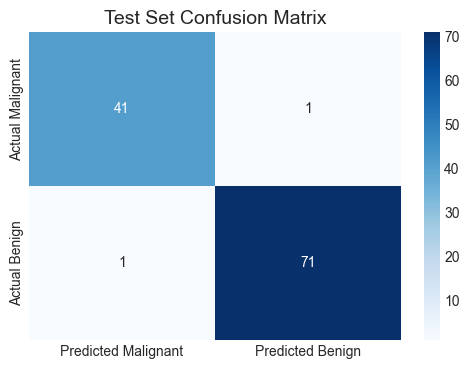

In [9]:
# ============================================================
# SECTION 8.1 & 8.2 — FINAL TEST EVAL & CONFUSION MATRIX
# ============================================================

# Generate final predictions on the completely unseen Test Set
y_test_pred = log_reg.predict(X_test_scaled)
y_test_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== FINAL TEST SET CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_test_pred, target_names=['Malignant (0)', 'Benign (1)']))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Test Set Confusion Matrix', fontsize=14)
plt.show()



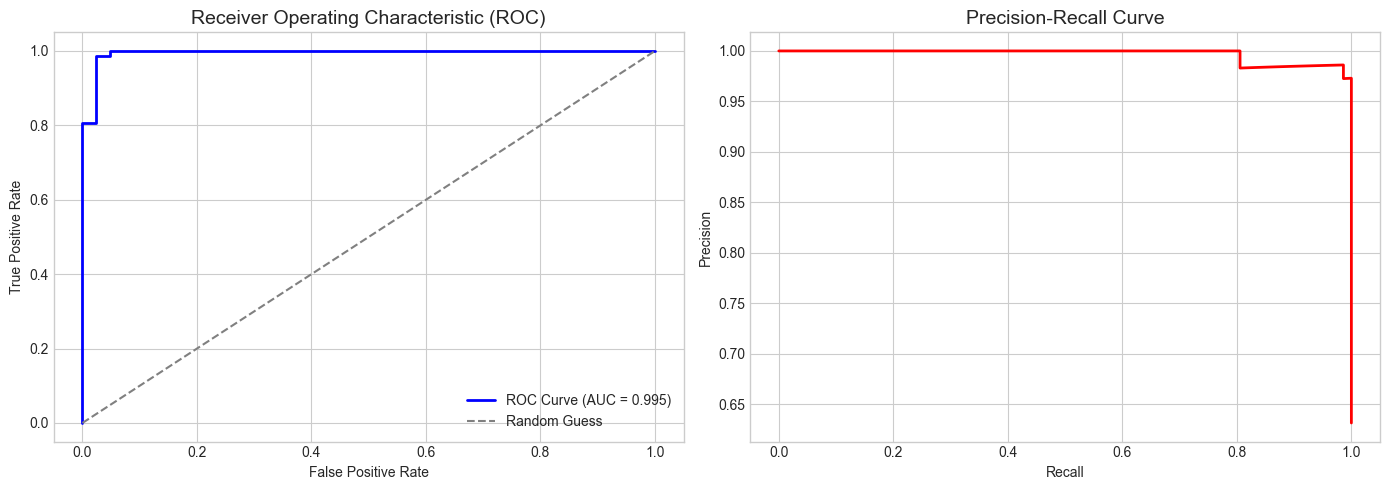

In [10]:
# ============================================================
# SECTION 8.3 — ROC AND PRECISION-RECALL CURVES
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_prob)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_test_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ROC Curve
axes[0].plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_prob):.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Plot Precision-Recall Curve
axes[1].plot(recall_vals, precision_vals, color='red', lw=2)
axes[1].set_title('Precision-Recall Curve', fontsize=14)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')

plt.tight_layout()
plt.show()



## 9. Optimization & Hyperparameter Tuning


### 💡 TIP: Tuning Parameters for Logistic Regression
The most impactful hyperparameter to tune in LR is `C` (Inverse of regularization strength). 
- Finding the \right `C` prevents overfitting or underfitting.
- Trying different penalties (`l1` vs `l2`) can also help, especially if you suspect many features are useless (L1 will push their weights to exactly 0).
- You must match the penalty with a compatible solver (e.g., `liblinear` or `saga` for L1).



In [11]:
# ============================================================
# SECTION 9.1 — GRIDSEARCHCV
# ============================================================

# Define the parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'] # NOTE: Both support L1 and L2
}

# Initialize a base model
base_lr = LogisticRegression(max_iter=2000, random_state=42)

# Setup GridSearchCV
# TIP: We use scoring='roc_auc' as it's a robust metric for binary classification
grid_search = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1, # Use all processor cores
    verbose=1
)

# We fit on the full temp set (Train + Val) because GridSearch does its own internal CV
grid_search.fit(X_temp_scaled, y_temp)



Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [12]:
# ============================================================
# SECTION 9.2 — BEST PARAMETERS & RETRAIN
# ============================================================

print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best CV ROC-AUC Score: {grid_search.best_score_:.4f}")

# The best model is automatically saved in best_estimator_
best_model = grid_search.best_estimator_

# Final evaluation with the tuned model on the Unseen Test Set
y_test_pred_opt = best_model.predict(X_test_scaled)
opt_acc = accuracy_score(y_test, y_test_pred_opt)

print(f"\nOptimized Model Test Accuracy: {opt_acc:.4f}")
print("Optimized Classification Report:")
print(classification_report(y_test, y_test_pred_opt))



Best Parameters Found: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC-AUC Score: 0.9941

Optimized Model Test Accuracy: 0.9825
Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 10. Multiclass Extension (Iris Dataset)
Logistic regression naturally handles Binary classification. But what if we have more than 2 classes?
There are two main strategies:
1. **One-vs-Rest (OvR):** The model trains one binary classifier per class (e.g., Class 1 vs Not Class 1).
2. **Multinomial (Softmax):** The loss function is expanded to cross-entropy across all classes simultaneously. Sklearn handles this automatically when `multi_class='multinomial'` is set.



In [13]:
# ============================================================
# MULTICLASS LOGISTIC REGRESSION
# ============================================================
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Split and Scale
X_ir_train, X_ir_test, y_ir_train, y_ir_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)
scaler_ir = StandardScaler()
X_ir_train_sc = scaler_ir.fit_transform(X_ir_train)
X_ir_test_sc = scaler_ir.transform(X_ir_test)

# Train Multinomial Logistic Regression
# TIP: multi_class='multinomial' uses the Softmax function
multi_lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
multi_lr.fit(X_ir_train_sc, y_ir_train)

# Evaluate
ir_preds = multi_lr.predict(X_ir_test_sc)
print("--- Iris Multiclass Report ---")
print(classification_report(y_ir_test, ir_preds, target_names=iris.target_names))



--- Iris Multiclass Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 11. Tips & Tricks Summary

1. **Always Scale Your Data:** Regularization is sensitive to scale. Always use `StandardScaler` or `MinMaxScaler`.
2. **Avoid Multicollinearity:** If features are highly correlated, coefficients become unstable. Drop highly correlated features or use PCA.
3. **Handle Imbalanced Data:** If one class is rare, use `class_weight='balanced'` in Sklearn to adjust the weights automatically.
4. **Tune `C` carefully:** The `C` parameter controls regularization. GridSearch over logarithmic scales like `[0.01, 0.1, 1, 10, 100]`.
5. **Use L1 for Feature Selection:** If you have 1,000 features and suspect only 10 matter, use `penalty='l1'` with `solver='liblinear'`.
6. **Watch the Threshold:** You aren't locked to 0.5. Use `predict_proba` and find the optimal threshold using the Precision-Recall curve depending on your business logic.
7. **Solver Choice Matters:** Use `lbfgs` for small datasets, `saga` for massive datasets where speed is crucial.
8. **Check Feature Distributions:** Extreme outliers can warp the linear decision boundary. Consider clipping outliers or taking the log of heavily skewed features.
9. **Interpretability:** Extract coefficients using `.coef_`. Exponential of the coefficient gives the exact odds ratio!
10. **Baseline Model:** ALWAYS build a logistic regression model first before trying Deep Learning. It provides a solid performance baseline.



## 12. Conclusion

In this guide, we explored **Logistic Regression** from its deep mathematical roots (Sigmoid function, Log-Odds, Cross-Entropy) to a full Python implementation. We saw that despite being mathematically simple, it provides high-performance, incredibly interpretable results, and perfectly calibrated probabilities. 

Whether you are predicting tumor malignance, filtering spam, or doing complex multiclass categorization like with the Iris dataset, Logistic Regression remains an indispensable tool. It proves the age-old data science adage: **Sometimes, the simplest algorithms are the most powerful.**

